# Gesture Recognition

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'new image')

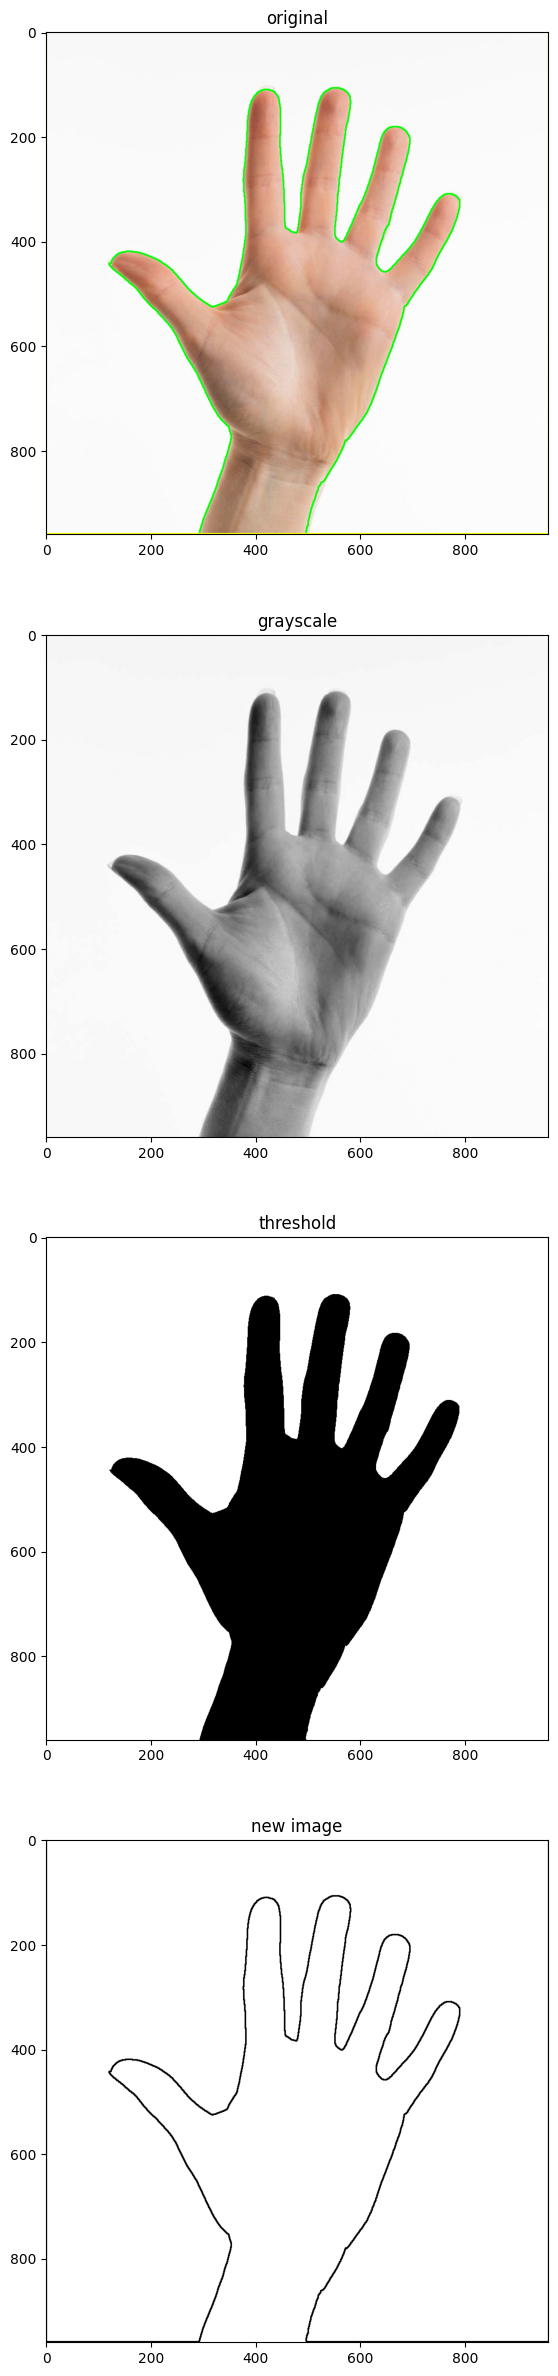

In [2]:

# load image
image = cv.imread("../images/hand.jpg")
image = cv.cvtColor(image,cv.COLOR_BGR2RGB)
# convert to gray and apply blur
gray = cv.cvtColor(image,cv.COLOR_RGB2GRAY)
blur = cv.GaussianBlur(gray,(7,7),0)

# apply threshhold and find contours
_,thresh = cv.threshold(blur,220,255,cv.THRESH_BINARY)
contours, _ = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
contour = max(contours, key=lambda x: cv.contourArea(x))
hull = [cv.convexHull(c) for c in contours]

# draw contours
new_img = np.ones(np.shape(thresh))
cv.drawContours(new_img,contours,-1,(0,255,0),2)
cv.drawContours(image,contours,-1,(0,255,0),2)
cv.drawContours(image,hull,-1,(255,255,0),2)
try:
    defects = cv.convexityDefects(contour,hull)
except:
    pass

# display image
fig = plt.figure(figsize=(30,30))

fig.add_subplot(4,1,1)
plt.title("original")
plt.imshow(image)
plt.title("original")

fig.add_subplot(4,1,2)
plt.imshow(gray,cmap = 'gray')
plt.title("grayscale")

fig.add_subplot(4,1,3)
plt.imshow(thresh , cmap = 'gray')
plt.title("threshold")

fig.add_subplot(4,1,4)
plt.imshow(new_img , cmap = 'gray')
plt.title("new image")